# Capítulo 18: Cadeias de Markov

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

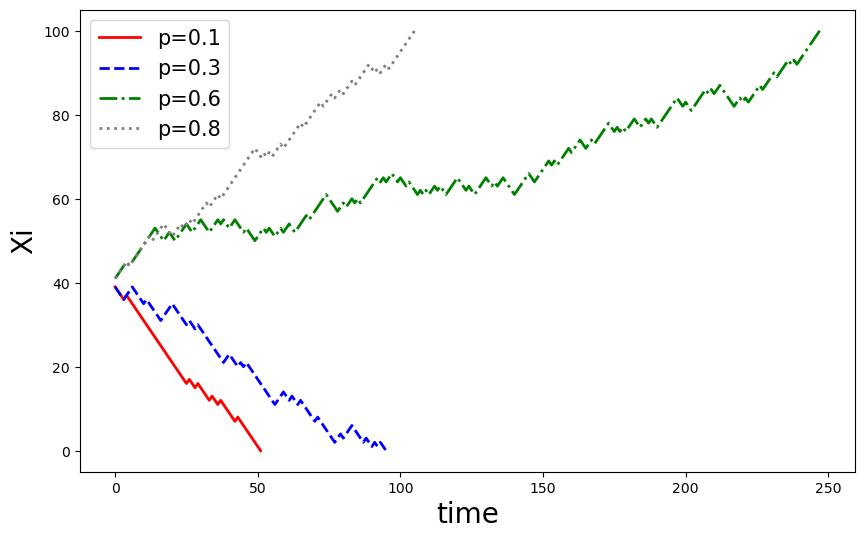

In [1]:
# Pág. 511
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(100)

# Valor máximo dos estados
N = 100
# Valores da probabilidade
vp = [0.1, 0.3, 0.6, 0.8]
colors = ['red', 'blue', 'green', 'gray']
lines = ['-','--', '-.', ':']
plt.figure(figsize=(10,6))
aux = 0
# para cada valor de p
for p in vp:
    i = 40
    t = 0
    vt = []
    vi = []
    # Inicia a caminhada
    while((i > 0) and (i < N)):
        if(np.random.uniform() < p):
            i = i + 1
        else:
            i = i - 1
        # armazena os estados
        vi.append(i)
        # armazena o tempo
        vt.append(t)
        t = t + 1
    # mostra os resultados
    plt.plot(vt, vi, linestyle=lines[aux], 
             color=colors[aux], linewidth=2, 
             label = 'p='+str(p))
    aux = aux + 1
plt.xlabel("time", fontsize=20)
plt.ylabel("Xi", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True) 

In [2]:
# Pág. 519
import numpy as np
from numpy.linalg import matrix_power

P = np.array([[1/4,1/2,1/4], 
              [1/3,0,2/3],
              [1/2,0,1/2]])
print("P = \n",P)
# calcula os autovalores e autovetores
eigvals, eigvecs = np.linalg.eig(P.T)
#seleciona o autovetor associado ao maior autovalor
eigvec1 = eigvecs[:, np.argmin(np.abs(eigvals - 1))]
stationary = (eigvec1 / eigvec1.sum()).real

print('pi = ',stationary)

# calculando a potência da matriz
n = 1000
Pn = matrix_power(P,n)
print("P**", n, ":\n", Pn)

P = 
 [[0.25       0.5        0.25      ]
 [0.33333333 0.         0.66666667]
 [0.5        0.         0.5       ]]
pi =  [0.375  0.1875 0.4375]
P** 1000 :
 [[0.375  0.1875 0.4375]
 [0.375  0.1875 0.4375]
 [0.375  0.1875 0.4375]]


In [3]:
# Pág. 522
import numpy as np
P = [[0.3,0.4,0.3], [0.1,0.3,0.6],[0.7,0,0.3]]
P = np.array(P)
print("P = \n",P)
P2 = np.matmul(P, P)
P3 = np.matmul(P2, P)
print("P^2 = \n", P2)
print("P^3 = \n", P3)

P = 
 [[0.3 0.4 0.3]
 [0.1 0.3 0.6]
 [0.7 0.  0.3]]
P^2 = 
 [[0.34 0.24 0.42]
 [0.48 0.13 0.39]
 [0.42 0.28 0.3 ]]
P^3 = 
 [[0.42  0.208 0.372]
 [0.43  0.231 0.339]
 [0.364 0.252 0.384]]


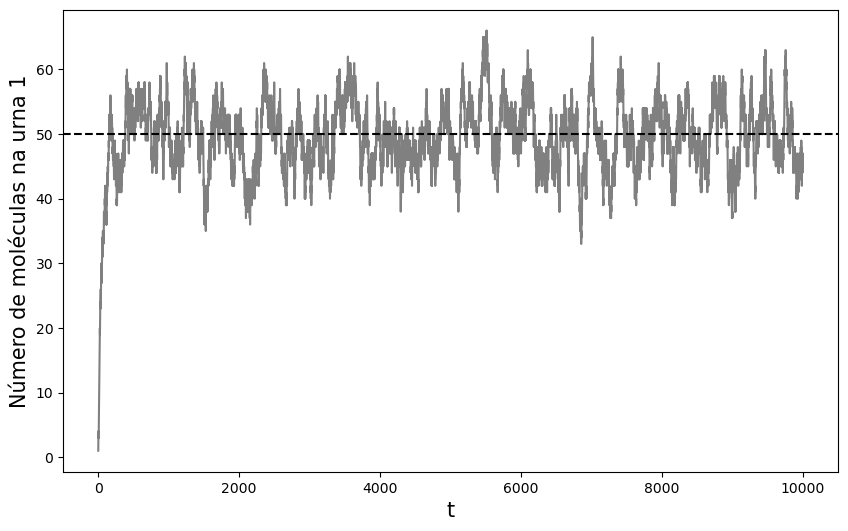

In [4]:
# Pág. 523
import numpy as np
import matplotlib.pyplot as plt

# Gerador de números aleatórios
rng = np.random.default_rng(42)
N = 100      # número de moléculas
T = 10_000   # número total de passos
# S[i] = 1 se a molécula i está na urna 1, 0 se está na urna 2
# Inicialmente, todas na urna 2
S = np.zeros(N, dtype=np.int8)

# Trajetória: número de moléculas na urna 1 ao longo do tempo
number = np.empty(T, dtype=int)

for t in range(T):
    # escolhe uma molécula em {0,...,N-1}
    i = rng.integers(N)
    # troca de urna de forma explícita
    if S[i] == 0:            # estava na urna 2
        S[i] = 1             # vai para a urna 1
    else:                    # estava na urna 1
        S[i] = 0             # vai para a urna 2
    number[t] = S.sum()      # número na urna 1

# Mostra os resultados
plt.figure(figsize=(10,6))
plt.plot(number, color='gray', linestyle='-')
plt.axhline(y=N/2, color='black', linestyle='--')
plt.xlabel('t', fontsize = 15)
plt.ylabel('Número de moléculas na urna 1',fontsize =15)
plt.show(True)

In [5]:
# Pág. 526
import numpy as np

p = 0.5 # probabilidade de movimentação
P = np.array([[0,p,0,0,1-p], [1-p,0,p,0,0],
              [0,1-p,0,p,0],[0,0,1-p,0,p],
              [p,0,0,1-p,0]])
print("P = \n",P)
# calcula os autovalores e autovetores
eigvals, eigvecs = np.linalg.eig(P.T)
eigvec1 = eigvecs[:,np.isclose(eigvals, 1)]
# seleciona o autovetor associado ao maior autovalor
eigvec1 = eigvec1[:,0]
stationary = eigvec1 / eigvec1.sum()
stationary = stationary.real
print('pi = ',stationary)

P = 
 [[0.  0.5 0.  0.  0.5]
 [0.5 0.  0.5 0.  0. ]
 [0.  0.5 0.  0.5 0. ]
 [0.  0.  0.5 0.  0.5]
 [0.5 0.  0.  0.5 0. ]]
pi =  [0.2 0.2 0.2 0.2 0.2]


In [6]:
# Pág. 526
import numpy as np

P = np.array([[0.9,0.1], 
              [0.2, 0.8]])
print("P = \n",P)
# calcula os autovalores e autovetores
eigvals, eigvecs = np.linalg.eig(P.T)
# seleciona o autovetor
eigvec1 = eigvecs[:, np.argmin(np.abs(eigvals - 1))]
stationary = (eigvec1 / eigvec1.sum()).real
print('pi = ',stationary)

P = 
 [[0.9 0.1]
 [0.2 0.8]]
pi =  [0.66666667 0.33333333]
